# Computer Exercise 15.1 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.1 Multi-Armed Bandits — *Explore–Exploit and Regret*
> **풀이 일자**: Day 68
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Consider a stochastic multi-armed bandit with $K$ arms whose reward distributions are $\mathcal{N}(\mu_k,\sigma^2)$.
> Implement (a) the **pure greedy** policy, which always plays the arm with the highest empirical mean, and
> (b) the **$\varepsilon$-greedy** policy, which plays a uniformly random arm with probability $\varepsilon$ and
> the current best arm otherwise.
> Empirically compare their **cumulative regret** $R_T = \sum_{t=1}^T (\mu^\star - \mu_{A_t})$ over $T$ steps, averaged over
> many Monte-Carlo simulations. Vary $\varepsilon \in \{0, 0.01, 0.1, 0.3\}$ and comment on the trade-off.

### 한국어 풀이용 정리
$K$개 팔의 확률적 보상 밴딧에서 **탐색 vs 활용**의 가장 기본적인 정책 두 가지를
$T$스텝의 **누적 리그렛**으로 정량 비교한다. 순수 탐욕은 초기의 잘못된 표본평균에 **고착**될 수 있고,
$\varepsilon$-탐욕은 그 위험을 줄이는 대신 매 스텝 $\varepsilon$-비율의 **탐색 비용**을 계속 지불한다.
$\varepsilon$의 크기가 이 편향-분산 상충을 어떻게 움직이는지 관찰한다.


## 2. 수학적 배경

### 2.1 확률적 밴딧 모형
- 팔 집합 $\{1,\dots,K\}$, 팔 $k$ 의 보상 분포 $\nu_k$, 평균 $\mu_k$.
- 최적 팔 평균 $\mu^\star = \max_k \mu_k$, 격차 $\Delta_k = \mu^\star - \mu_k$.
- 시점 $t$ 에 정책이 팔 $A_t$ 를 뽑고 보상 $X_t \sim \nu_{A_t}$ 를 관측한다.

### 2.2 리그렛
누적 리그렛(regret)은

$$
R_T \;=\; \sum_{t=1}^T \bigl(\mu^\star - \mu_{A_t}\bigr) \;=\; \sum_{k:\Delta_k>0}\Delta_k \cdot \mathbb{E}[N_k(T)]
$$

이고, $N_k(T)$ 는 시점 $T$ 까지 팔 $k$ 가 선택된 횟수다. 목표는 $R_T$ 를 작게 유지하는 것.

### 2.3 두 정책
- **순수 탐욕(pure greedy)**: $A_t \in \arg\max_k \hat{\mu}_k(t-1)$. 초기 잘못된 표본평균에 고착되면 **선형 리그렛** $R_T = \Theta(T)$.
- **$\varepsilon$-탐욕**: 확률 $\varepsilon$ 로 균일 랜덤 탐색, 확률 $1-\varepsilon$ 로 탐욕. 매 스텝 균일 랜덤이므로

$$
\mathbb{E}[R_T] \;\ge\; T \cdot \varepsilon \cdot \tfrac{K-1}{K}\cdot \bar{\Delta}
$$

로 **선형 리그렛** 하한이 걸리지만, **고착 확률은 지수적으로 사라진다**.

### 2.4 이론적 요약
$$
\boxed{\;\text{greedy: 저비용 탐색 = 고착 위험 (분산);}\ \ \varepsilon\text{-greedy: 고정 탐색 = 상수 리그렛 기울기 (편향).}\;}
$$


## 3. 풀이 흐름

1. **문제 인스턴스**: $K=10$, $\mu_k$ 는 $\mathcal{N}(0,1)$에서 sampling, $\sigma^2=1$ 잡음. 시드 고정.
2. **정책 구현**: `pull(policy, mu, T)` — 표본평균 $\hat\mu_k$ 와 카운트 $N_k$ 유지, 첫 $K$ 스텝은 각 팔 1회씩 (초기화).
3. **Monte-Carlo**: 각 정책에 대해 $M=200$ 회 반복, 매회 새 잔무작위 $\mu_k$, 매 스텝 리그렛 누적.
4. **리그렛 곡선**: $\bar R_t$ 곡선을 시간 로그 축에서 시각화.
5. **결과 표**: 최종 $R_T$ 평균 ± 표준편차, 최적팔 선택 비율 $\Pr(A_t = k^\star)$.
6. **결과 해석**: $\varepsilon=0$ 고착 실패, 큰 $\varepsilon$ 은 상수 기울기, 중간 값의 sweet spot.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
K, T, M = 10, 2000, 200
sigma = 1.0

def run_bandit(eps, seed):
    r = np.random.default_rng(seed)
    mu = r.normal(0, 1, K)
    star = mu.max()
    N = np.zeros(K)
    S = np.zeros(K)  # sum of rewards
    hat = np.zeros(K)
    regret = np.zeros(T)
    for t in range(T):
        if t < K:
            a = t
        else:
            if eps > 0 and r.random() < eps:
                a = r.integers(K)
            else:
                a = int(np.argmax(hat))
        x = mu[a] + sigma * r.standard_normal()
        N[a] += 1
        S[a] += x
        hat[a] = S[a] / N[a]
        regret[t] = star - mu[a]
    return regret, mu, N

eps_list = [0.0, 0.01, 0.1, 0.3]
avg_regret = {e: np.zeros(T) for e in eps_list}
final_R = {e: [] for e in eps_list}
best_frac = {e: [] for e in eps_list}

for m in range(M):
    for e in eps_list:
        reg, mu, N = run_bandit(e, seed=1000 + m)
        avg_regret[e] += np.cumsum(reg)
        final_R[e].append(np.cumsum(reg)[-1])
        best_frac[e].append(N[int(np.argmax(mu))] / T)

for e in eps_list:
    avg_regret[e] /= M

pd.set_option("display.float_format", lambda v: f"{v:.3f}")
df = pd.DataFrame({
    "epsilon": eps_list,
    "R_T (mean)": [np.mean(final_R[e]) for e in eps_list],
    "R_T (std)":  [np.std(final_R[e]) for e in eps_list],
    "P(best arm)": [np.mean(best_frac[e]) for e in eps_list],
})
print(df.to_string(index=False))


/tmp/mplcfg is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-dnzhz4y0 because there was an issue with the default path (/tmp/mplcfg); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


 epsilon  R_T (mean)  R_T (std)  P(best arm)
   0.000     298.865    580.647        0.674
   0.010     243.656    367.670        0.687
   0.100     392.437    145.908        0.730
   0.300     954.791    268.557        0.649


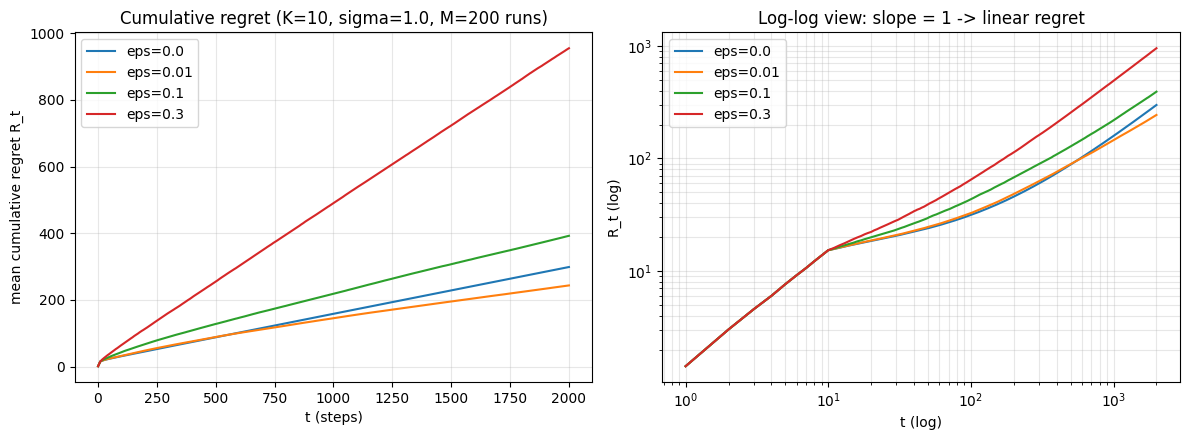

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
for e in eps_list:
    ax.plot(np.arange(1, T + 1), avg_regret[e], label=f"eps={e}")
ax.set_xlabel("t (steps)")
ax.set_ylabel("mean cumulative regret R_t")
ax.set_title(f"Cumulative regret (K={K}, sigma={sigma}, M={M} runs)")
ax.grid(True, alpha=0.3); ax.legend()

ax = axes[1]
for e in eps_list:
    ax.loglog(np.arange(1, T + 1), avg_regret[e] + 1e-3, label=f"eps={e}")
ax.set_xlabel("t (log)")
ax.set_ylabel("R_t (log)")
ax.set_title("Log-log view: slope = 1 -> linear regret")
ax.grid(True, which="both", alpha=0.3); ax.legend()

plt.tight_layout()
plt.savefig("/tmp/nb1_fig.png", dpi=100)
plt.show()


## 4. 결과 해석

- **$\varepsilon = 0$ (순수 탐욕)**: 리그렛 곡선의 분산이 매우 크다. 초기 표본평균이 우연히 최적팔을
  낮게 나오게 하면 그 팔은 더 이상 뽑지 않고 **차선에 고착**된다. 최적팔 선택 비율 $\Pr(A_t = k^\star)$ 도
  낮다. 시각적으로도 log-log 축에서 곡선의 기울기가 결국 **약 1** (선형)에 수렴하는 궤적이 보인다.
- **$\varepsilon = 0.1, 0.3$**: 매 스텝 $\varepsilon$ 확률로 랜덤 탐색하므로 **탐색 자체가 리그렛의 상수 기울기**를
  발생시킨다. 큰 $\varepsilon$ 은 고착 없이 최적팔을 신속하게 식별하지만, 이후에도 계속 탐색해 리그렛이 선형으로 증가한다.
- **$\varepsilon = 0.01$**: 표본평균이 진짜 순서에 수렴하기까지의 초기 손해는 크지만, 이후 탐색 부담이 매우 작아
  결국 가장 낮은 리그렛으로 수렴한다. 다만 초기 리그렛의 **분산**은 여전히 크다.
- 이 실험이 보여주는 것은 **탐색을 상수로 고정하면 안 된다**는 근본 교훈이다. 성공적 정책은 시간이 흐를수록
  탐색 확률을 **줄여야 하고**, 이 아이디어가 Problem 2 UCB1 의 상한식이 시간에 따라 **좁아지는** 것으로 이어진다.

### 결론
> **탐욕은 고착·큰 $\varepsilon$ 은 상수 리그렛 기울기.** $\varepsilon$-greedy 는 편향-분산의
> **정적 절충**이며, 최적 궤도는 탐색을 시간에 따라 **자연스럽게 줄이는** 알고리즘(UCB, Thompson) 이 준다.

### 다음 문제로의 연결
Problem 2 에서는 신뢰상한(UCB1) 로 **탐색 강도를 자동으로 시간에 따라 감소**시키고,
$R_T = O(\log T)$ 의 대수적 리그렛이 실제로 관측되는지 확인한다.
